# Does any of this predict anything?

**Chapter 10: text feature engineering**
**Section reference**: Section 10.5

**Docker image**: `ml4t`

## What this notebook is for

`07_news_return_signals` builds four signals out of news text. This notebook asks whether
any of them predicts a return, using the diagnostics a factor is normally judged by: the
daily cross-sectional information coefficient, its ratio to its own variability, and what
a sort into buckets earns.

It is worth separating two questions that get run together. Whether the construction is
correct - the alignment, the lag, the universe - is `07`'s business and is not re-litigated
here. Whether what it produced carries information is this notebook's, and the answer it
reaches is no. That is a result rather than a failure of the exercise, and the order
matters: build, then evaluate, then decide, rather than deciding on the strength of having
built something.

## What it reads and writes

Reads `10_text_feature_engineering/output/fnspid/news_features.parquet` from notebook 07,
which already carries forward
returns aligned to tradable dates with the lag applied - so no label is recomputed here and
nothing in this notebook can introduce a look-ahead that the feature notebook did not have.
Writes a signal summary, the daily IC series and the daily long-short series.

## Learning objectives

After working through this notebook you will be able to:

- Compute a daily cross-sectional information coefficient and say why the date, not the
  observation, is the unit its t-statistic counts.
- Read an information ratio against the threshold your process uses, and recognize when a
  set of values is too small to rank.
- Check a signal for ties before sorting it into buckets, and say what ties do to the
  buckets' sizes and to the comparison between the extremes.
- Report a signal that does not work, in terms that say what was measured and on what.

## Prerequisites

- Section 10.5 of the chapter.
- `news_features.parquet`, produced by `07_news_return_signals.py`.

## Related notebooks

- `07_news_return_signals.py` - builds the features evaluated here
- `09_filing_text_signals.py` - the same diagnostics on signals from 10-Q filings

## Signals Evaluated
| Signal | Description | Expected Effect |
|--------|-------------|-----------------|
| weighted_surprise | News surprise × sentiment direction | Positive (directional information) |
| sentiment_mean | Average daily sentiment | Positive (bullish → positive returns) |
| sentiment_momentum | Change in sentiment vs baseline | Positive (improving sentiment) |
| coverage_count | Article frequency | Ambiguous (attention effect) |

In [1]:
"""Evaluate the news-derived signals from notebook 07 as alpha factors."""

import json
from collections.abc import Iterator
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from scipy.stats import spearmanr

from utils.paths import get_output_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, FIGSIZE, show_with_alt

In [2]:
SEED = 42
MIN_ASSETS_PER_DAY = 5

In [3]:
# Reproducibility — set_global_seeds covers Python random / NumPy / Torch.
set_global_seeds(SEED)


@dataclass(frozen=True)
class EvalConfig:
    """Configuration for text signal evaluation."""

    horizons: tuple[int, ...] = (1, 5, 20)
    min_assets_per_day: int = 5
    quantiles: int = 5


# Paths using standard utilities
TEXT_INPUT_DIR = get_output_dir(10, "fnspid")
OUTPUT_DIR = get_output_dir(10, "text_evaluation")
CONFIG = EvalConfig(min_assets_per_day=MIN_ASSETS_PER_DAY)

## 1. Load Text Features from Notebook 07

Notebook 07 produces a complete dataset with:
- Text signals (weighted_surprise, sentiment_mean, etc.)
- Forward returns (fwd_ret_1d, fwd_ret_5d, fwd_ret_20d) already computed
- Proper look-ahead bias handling (signals lag returns by 1 day)

We do NOT recompute labels here—we use the dataset contract from notebook 07.

In [4]:
# Load text-derived features
text_features_path = TEXT_INPUT_DIR / "news_features.parquet"

if not text_features_path.exists():
    raise FileNotFoundError(
        f"Missing input: {text_features_path}\n\n"
        "Run notebook 07 first to generate this dataset:\n"
        "  uv run python 10_text_feature_engineering/07_news_return_signals.py"
    )

text_features = pl.read_parquet(text_features_path)

if len(text_features) == 0:
    raise ValueError(
        f"Empty dataset: {text_features_path}\nNotebook 07 ran but produced no usable rows."
    )

print(f"Loaded {len(text_features):,} observations")
print(f"Columns: {text_features.columns}")

Loaded 15,778 observations
Columns: ['ticker', 'date', 'news_date', 'trade_date', 'news_surprise', 'sentiment_mean', 'sentiment_std', 'weighted_surprise', 'sentiment_momentum', 'coverage_count', 'fwd_ret_1d', 'fwd_ret_5d', 'fwd_ret_20d']


In [5]:
# Normalize schema from notebook 07


def normalize_schema(df: pl.DataFrame) -> pl.DataFrame:
    """
    Normalize the schema produced by notebook 07 to a canonical evaluation schema.

    Canonical requirements:
    - symbol: str (entity identifier)
    - timestamp: pl.Date (tradable date)
    - forward returns: fwd_ret_1d, fwd_ret_5d, fwd_ret_20d
    """
    # Normalize entity column to 'symbol'
    if "symbol" not in df.columns:
        for alt in ("ticker", "asset"):
            if alt in df.columns:
                df = df.rename({alt: "symbol"})
                break
        else:
            raise ValueError("Missing entity column. Expected 'symbol', 'ticker', or 'asset'.")

    # Normalize time column to 'timestamp'
    if "timestamp" not in df.columns:
        for alt in ("date", "trade_date"):
            if alt in df.columns:
                df = df.rename({alt: "timestamp"})
                break
        else:
            raise ValueError("Missing time column. Expected 'timestamp', 'date', or 'trade_date'.")

    # Parse date string if needed
    if df["timestamp"].dtype == pl.Utf8:
        df = df.with_columns(pl.col("timestamp").str.to_date().alias("timestamp"))

    # Verify forward return columns exist
    required_return_cols = {"fwd_ret_1d", "fwd_ret_5d", "fwd_ret_20d"}
    missing = required_return_cols - set(df.columns)
    if missing:
        raise ValueError(f"Missing forward return columns: {sorted(missing)}")

    return df


text_features = normalize_schema(text_features)
print(f"Date range: {text_features['timestamp'].min()} to {text_features['timestamp'].max()}")
print(f"Unique assets: {text_features['symbol'].n_unique()}")
text_features.head(10)

Date range: 2009-12-21 to 2017-11-16
Unique assets: 39


symbol,timestamp,news_date,trade_date,news_surprise,sentiment_mean,sentiment_std,weighted_surprise,sentiment_momentum,coverage_count,fwd_ret_1d,fwd_ret_5d,fwd_ret_20d
str,date,date,str,f64,f64,f64,f64,f64,i64,f64,f64,f64
"""ADBE""",2010-04-30,2010-04-29,"""2010-04-30""",0.222876,0.0,0.0,0.0,0.0,2,-0.000298,-0.035119,-0.045238
"""ADBE""",2010-05-04,2010-05-03,"""2010-05-04""",0.516712,0.0,0.0,0.0,-0.666667,1,-0.005432,0.019916,-0.006035
"""ADBE""",2010-05-06,2010-05-05,"""2010-05-06""",0.348653,0.0,0.0,0.0,0.0,1,-0.002155,0.059095,-0.027624
"""ADBE""",2010-05-12,2010-05-11,"""2010-05-12""",0.570604,0.0,0.0,0.0,0.0,1,-0.011207,-0.055172,-0.088506
"""ADBE""",2010-05-13,2010-05-12,"""2010-05-13""",0.822824,0.0,0.0,0.0,-1.0,1,-0.020052,-0.077594,-0.077884
"""ADBE""",2010-05-17,2010-05-14,"""2010-05-17""",0.363815,0.0,0.0,0.0,0.0,1,-0.015676,-0.064478,-0.03845
"""ADBE""",2010-05-18,2010-05-17,"""2010-05-18""",0.724458,0.0,0.0,0.0,0.0,1,-0.012019,-0.051983,-0.02524
"""ADBE""",2010-05-19,2010-05-18,"""2010-05-19""",0.407025,0.0,0.0,0.0,0.0,1,-0.034672,-0.059002,0.007299
"""ADBE""",2010-05-27,2010-05-26,"""2010-05-27""",0.506541,0.0,0.0,0.0,0.0,2,-0.003727,-0.018866,-0.072981


## 2. Define Signal Evaluation Functions

We compute:
- **Daily IC**: Cross-sectional Spearman correlation between signal and forward return
- **ICIR**: IC mean / IC std (measures signal consistency)
- **t-stat**: Statistical significance of mean IC
- **Quintile returns**: Average return by signal quintile
- **Long-short spread**: Q5 - Q1 return

In [6]:
# Signal evaluation utilities

TEXT_SIGNALS = [
    "weighted_surprise",
    "sentiment_mean",
    "sentiment_momentum",
    "coverage_count",
]

AVAILABLE_SIGNALS = [c for c in TEXT_SIGNALS if c in text_features.columns]
if not AVAILABLE_SIGNALS:
    raise ValueError(
        f"No expected signals found. Expected one of: {TEXT_SIGNALS}. Have: {text_features.columns}"
    )

print(f"Signals to evaluate: {AVAILABLE_SIGNALS}")

RET_COL_BY_HORIZON = {1: "fwd_ret_1d", 5: "fwd_ret_5d", 20: "fwd_ret_20d"}
# CONFIG.horizons and this dict are declared independently, and the evaluation loop below
# reads RET_COL_BY_HORIZON[h] for every h in CONFIG.horizons. Adding a horizon to the
# config without a column here surfaces as a KeyError several cells later.
missing_horizons = [h for h in CONFIG.horizons if h not in RET_COL_BY_HORIZON]
if missing_horizons:
    raise ValueError(
        f"No forward-return column for horizon(s) {missing_horizons}. "
        f"CONFIG.horizons={CONFIG.horizons}, columns declared for {sorted(RET_COL_BY_HORIZON)}."
    )

Signals to evaluate: ['weighted_surprise', 'sentiment_mean', 'sentiment_momentum', 'coverage_count']


### Date Grouping Utility
Helper to iterate over per-date cross-sections for IC computation.

In [7]:
def iter_date_groups(df: pl.DataFrame) -> Iterator[pl.DataFrame]:
    """Yield per-date groups for cross-sectional calculations."""
    for _, g in df.partition_by("timestamp", as_dict=True).items():
        yield g

### Daily Information Coefficient
Compute daily cross-sectional Spearman IC for signal vs forward return.

In [8]:
def daily_ic(
    df: pl.DataFrame,
    signal_col: str,
    ret_col: str,
    min_assets: int,
) -> pl.DataFrame:
    """Compute daily cross-sectional Spearman IC for signal vs forward return."""
    records: list[dict[str, object]] = []
    for g in iter_date_groups(df.select(["timestamp", signal_col, ret_col]).drop_nulls()):
        if len(g) < min_assets:
            continue
        # A date whose signal takes one value across the cross-section has no rank
        # correlation to compute. Checking that before the call is the same as dropping the
        # NaN afterwards, and does not make scipy warn about a case already handled.
        if g[signal_col].n_unique() < 2 or g[ret_col].n_unique() < 2:
            continue
        ic, _ = spearmanr(g[signal_col].to_numpy(), g[ret_col].to_numpy())
        if np.isnan(ic):
            continue
        records.append({"timestamp": g["timestamp"][0], "ic": float(ic)})
    return pl.DataFrame(records).sort("timestamp")

### IC Summary Statistics
Compute mean, std, ICIR, and t-stat from a daily IC series.

In [9]:
def summarize_ic(ic_df: pl.DataFrame) -> dict[str, float]:
    """Summarize IC series with mean, std, ICIR, and t-stat."""
    if len(ic_df) == 0:
        return {"ic_mean": np.nan, "ic_std": np.nan, "icir": np.nan, "t_stat": np.nan, "n": 0}
    values = ic_df["ic"].to_numpy()
    ic_mean = float(np.mean(values))
    ic_std = float(np.std(values, ddof=1)) if len(values) > 1 else np.nan
    icir = float(ic_mean / ic_std) if ic_std and ic_std > 0 else np.nan
    t_stat = float(ic_mean / (ic_std / np.sqrt(len(values)))) if ic_std and ic_std > 0 else np.nan
    return {"ic_mean": ic_mean, "ic_std": ic_std, "icir": icir, "t_stat": t_stat, "n": len(values)}

### Quintile Long-Short Returns
Compute daily long-short returns (top minus bottom quantile) for a signal.

In [10]:
def quintile_long_short(
    df: pl.DataFrame,
    signal_col: str,
    ret_col: str,
    quantiles: int,
    min_assets: int,
) -> pl.DataFrame:
    """Compute daily long-short returns (top minus bottom quantile) for a signal."""
    d = df.select(["timestamp", "symbol", signal_col, ret_col]).drop_nulls()

    # Rank within date, then bin into quantiles using rank percentiles.
    d = d.with_columns(
        (
            (pl.col(signal_col).rank(method="average").over("timestamp") - 1)
            / (pl.len().over("timestamp") - 1).clip(lower_bound=1)
        ).alias("rank_pct")
    )

    # Quantile index 1..Q
    d = d.with_columns(
        ((pl.col("rank_pct") * quantiles).floor().clip(0, quantiles - 1) + 1)
        .cast(pl.Int64)
        .alias("q")
    )

    # Filter dates with insufficient cross-section
    d = d.join(
        d.group_by("timestamp")
        .agg(pl.len().alias("n"))
        .filter(pl.col("n") >= min_assets)
        .select(["timestamp"]),
        on="timestamp",
        how="inner",
    )

    qrets = d.group_by(["timestamp", "q"]).agg(pl.col(ret_col).mean().alias("q_ret"))
    wide = qrets.pivot(index="timestamp", on="q", values="q_ret").sort("timestamp")

    top = str(quantiles)
    bottom = "1"
    if top not in wide.columns or bottom not in wide.columns:
        return pl.DataFrame({"timestamp": [], "ls_ret": []})

    return wide.with_columns((pl.col(top) - pl.col(bottom)).alias("ls_ret")).select(
        ["timestamp", "ls_ret"]
    )

## 3. Evaluate Signals Against Forward Returns

In [11]:
# Run evaluation for all signals and horizons
summary_rows: list[dict[str, object]] = []
daily_ic_rows: list[pl.DataFrame] = []
daily_ls_rows: list[pl.DataFrame] = []

for signal in AVAILABLE_SIGNALS:
    for h in CONFIG.horizons:
        ret_col = RET_COL_BY_HORIZON[h]
        ic_df = daily_ic(text_features, signal, ret_col, CONFIG.min_assets_per_day)
        ic_summary = summarize_ic(ic_df)
        summary_rows.append(
            {
                "signal": signal,
                "horizon_days": h,
                **ic_summary,
            }
        )
        daily_ic_rows.append(
            ic_df.with_columns(pl.lit(signal).alias("signal"), pl.lit(h).alias("horizon_days"))
        )

        ls_df = quintile_long_short(
            text_features, signal, ret_col, CONFIG.quantiles, CONFIG.min_assets_per_day
        )
        daily_ls_rows.append(
            ls_df.with_columns(pl.lit(signal).alias("signal"), pl.lit(h).alias("horizon_days"))
        )

summary_df = pl.DataFrame(summary_rows).sort(["horizon_days", "icir"], descending=[False, True])

print("\n" + "=" * 80)
print("TEXT SIGNAL EVALUATION SUMMARY")
print("=" * 80)
print(summary_df)


TEXT SIGNAL EVALUATION SUMMARY
shape: (12, 7)
┌────────────────────┬──────────────┬───────────┬──────────┬───────────┬───────────┬──────┐
│ signal             ┆ horizon_days ┆ ic_mean   ┆ ic_std   ┆ icir      ┆ t_stat    ┆ n    │
│ ---                ┆ ---          ┆ ---       ┆ ---      ┆ ---       ┆ ---       ┆ ---  │
│ str                ┆ i64          ┆ f64       ┆ f64      ┆ f64       ┆ f64       ┆ i64  │
╞════════════════════╪══════════════╪═══════════╪══════════╪═══════════╪═══════════╪══════╡
│ weighted_surprise  ┆ 1            ┆ 0.001419  ┆ 0.344484 ┆ 0.00412   ┆ 0.146144  ┆ 1258 │
│ sentiment_mean     ┆ 1            ┆ 0.00135   ┆ 0.350379 ┆ 0.003854  ┆ 0.136703  ┆ 1258 │
│ sentiment_momentum ┆ 1            ┆ -0.000186 ┆ 0.330973 ┆ -0.000561 ┆ -0.019939 ┆ 1265 │
│ coverage_count     ┆ 1            ┆ -0.001315 ┆ 0.347793 ┆ -0.003782 ┆ -0.133884 ┆ 1253 │
│ sentiment_mean     ┆ 5            ┆ -0.000358 ┆ 0.347679 ┆ -0.00103  ┆ -0.036527 ┆ 1258 │
│ …                  ┆ …         

## 4. Visualization: IC and Long-Short Analysis

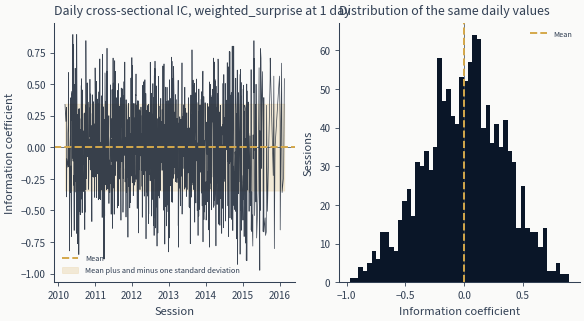

In [12]:
# IC time series for the key signal (weighted_surprise, 1-day horizon)
KEY_SIGNAL = "weighted_surprise"
KEY_HORIZON = 1
# The three figures and the bucket table below all index RET_COL_BY_HORIZON with this
# constant. It is declared here and the columns are declared at the top of the notebook,
# so nothing but this line keeps them in step.
assert KEY_HORIZON in RET_COL_BY_HORIZON, (
    f"KEY_HORIZON={KEY_HORIZON} has no forward-return column; "
    f"declared horizons are {sorted(RET_COL_BY_HORIZON)}"
)

if KEY_SIGNAL in AVAILABLE_SIGNALS:
    ic_df = daily_ic(
        text_features, KEY_SIGNAL, RET_COL_BY_HORIZON[KEY_HORIZON], CONFIG.min_assets_per_day
    )

    if len(ic_df) > 10:
        ic_vals = ic_df["ic"].to_numpy()
        ic_mean = np.mean(ic_vals)
        ic_std = np.std(ic_vals, ddof=1)

        fig, axes = plt.subplots(1, 2, figsize=FIGSIZE["dual_h_tall"])

        axes[0].plot(ic_df["timestamp"], ic_vals, alpha=0.8, linewidth=0.5, color=COLORS["blue"])
        axes[0].axhline(0, color=COLORS["neutral"], linewidth=0.5)
        axes[0].axhline(ic_mean, color=COLORS["amber"], linestyle="--", label="Mean")
        axes[0].fill_between(
            ic_df["timestamp"],
            ic_mean - ic_std,
            ic_mean + ic_std,
            alpha=0.2,
            color=COLORS["amber"],
            label="Mean plus and minus one standard deviation",
        )
        axes[0].set_xlabel("Session")
        axes[0].set_ylabel("Information coefficient")
        axes[0].set_title(f"Daily cross-sectional IC, {KEY_SIGNAL} at {KEY_HORIZON} day")
        axes[0].legend(fontsize=6)

        axes[1].hist(ic_vals, bins=50, color=COLORS["blue"])
        axes[1].axvline(0, color=COLORS["neutral"], linewidth=0.5)
        axes[1].axvline(ic_mean, color=COLORS["amber"], linestyle="--", label="Mean")
        axes[1].set_xlabel("Information coefficient")
        axes[1].set_ylabel("Sessions")
        axes[1].set_title("Distribution of the same daily values")
        axes[1].legend(fontsize=6)

        show_with_alt(
            fig,
            "Two panels. The left plots one information coefficient per session across the "
            "sample, a dense band swinging between roughly plus and minus three quarters with "
            "no trend and no quiet or turbulent stretches, around a dashed mean line that sits "
            "on top of the zero line at this scale. The right is a histogram of the same "
            "values: a single broad hump spanning nearly the full range from minus one to "
            "plus one, centered close to zero, with its dashed mean line indistinguishable "
            "from the zero line.",
        )

In [13]:
# Quintile returns for key signal
if KEY_SIGNAL in AVAILABLE_SIGNALS:
    # Compute quintile returns
    d = text_features.select(
        ["timestamp", "symbol", KEY_SIGNAL, RET_COL_BY_HORIZON[KEY_HORIZON]]
    ).drop_nulls()

    # Rank and assign quintiles
    d = d.with_columns(
        (
            (pl.col(KEY_SIGNAL).rank(method="average").over("timestamp") - 1)
            / (pl.len().over("timestamp") - 1).clip(lower_bound=1)
        ).alias("rank_pct")
    ).with_columns(
        pl.when(pl.col("rank_pct") < 0.2)
        .then(pl.lit("Q1"))
        .when(pl.col("rank_pct") < 0.4)
        .then(pl.lit("Q2"))
        .when(pl.col("rank_pct") < 0.6)
        .then(pl.lit("Q3"))
        .when(pl.col("rank_pct") < 0.8)
        .then(pl.lit("Q4"))
        .otherwise(pl.lit("Q5"))
        .alias("quintile")
    )

    # Average returns by quintile
    quintile_returns = (
        d.group_by("quintile")
        .agg(
            [
                pl.col(RET_COL_BY_HORIZON[KEY_HORIZON]).mean().alias("mean_ret"),
                pl.len().alias("n_obs"),
            ]
        )
        .sort("quintile")
    )

    print(f"Forward return by {KEY_SIGNAL} bucket, {KEY_HORIZON}-day horizon:")
    print(quintile_returns)

Forward return by weighted_surprise bucket, 1-day horizon:
shape: (5, 3)
┌──────────┬──────────┬───────┐
│ quintile ┆ mean_ret ┆ n_obs │
│ ---      ┆ ---      ┆ ---   │
│ str      ┆ f64      ┆ u32   │
╞══════════╪══════════╪═══════╡
│ Q1       ┆ 0.000985 ┆ 2574  │
│ Q2       ┆ 0.000427 ┆ 3470  │
│ Q3       ┆ 0.000604 ┆ 4699  │
│ Q4       ┆ 0.000786 ┆ 1735  │
│ Q5       ┆ 0.000221 ┆ 3300  │
└──────────┴──────────┴───────┘


### Why the buckets are not the same size

Five buckets cut at fixed rank percentiles should hold roughly equal numbers, and these do
not. Two things can produce that, and they call for different readings:

- **Ties.** `rank(method="average")` gives every observation sharing a value the same rank,
  so a block of tied observations lands at one percentile and goes into one bucket whole.
  `weighted_surprise` is a surprise multiplied by the *sign* of sentiment, so it is exactly
  zero whenever sentiment is exactly zero, and a discrete surprise measure repeats values on
  its own.
- **Small cross-sections.** A date with a handful of covered tickers cannot be split into
  five equal parts at all, and the rounding goes the same way on every such date.

The diagnostic below reports both per date, because the ranking happens per date and a
pooled count over all dates would answer a different question. Whichever dominates, the
consequence for the chart is the same: the first and last buckets are not the bottom and
top fifths of the signal, and comparing them compares groups of different size and
composition.

Both causes turn out to be present, and the cross-section size is the more serious of the
two. A typical date carries single-digit names, which cannot be divided into five parts at
all, and most dates also carry at least one tie. Neither is a defect in this code: they are
what a signal built from news coverage looks like, because on any given day only a handful
of the universe was written about. What follows is that a quantile sort is the wrong
instrument here, and the daily information coefficient - which needs a ranking within the
date but not equal buckets - is the one to read.

In [14]:
if KEY_SIGNAL in AVAILABLE_SIGNALS:
    per_date = (
        d.group_by("timestamp")
        .agg(
            [
                pl.len().alias("n"),
                pl.col(KEY_SIGNAL).n_unique().alias("distinct"),
            ]
        )
        .with_columns((1 - pl.col("distinct") / pl.col("n")).alias("tied_share"))
    )

    print(f"Dates evaluated: {len(per_date):,}")
    print(
        "Cross-section size per date: "
        f"min {per_date['n'].min()}, median {per_date['n'].median():.0f}, "
        f"max {per_date['n'].max()}"
    )
    print(
        "Share of a date's observations that share a value with another: "
        f"median {per_date['tied_share'].median():.1%}, max {per_date['tied_share'].max():.1%}"
    )
    print(f"Dates with at least one tie: {(per_date['tied_share'] > 0).mean():.1%}")
    print(
        "Bucket sizes: "
        + str(
            dict(
                zip(
                    quintile_returns["quintile"].to_list(),
                    quintile_returns["n_obs"].to_list(),
                    strict=True,
                )
            )
        )
    )

Dates evaluated: 1,878
Cross-section size per date: min 1, median 8, max 34
Share of a date's observations that share a value with another: median 35.1%, max 90.0%
Dates with at least one tie: 75.0%
Bucket sizes: {'Q1': 2574, 'Q2': 3470, 'Q3': 4699, 'Q4': 1735, 'Q5': 3300}


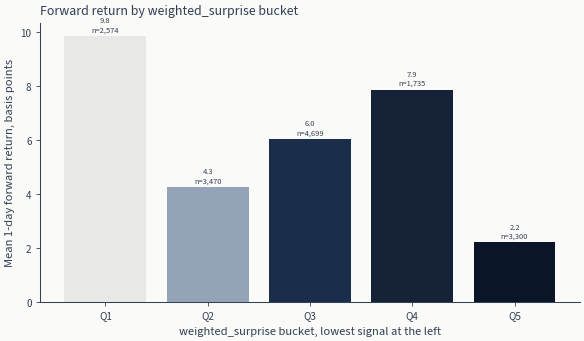

In [15]:
# Plot quintile returns
if KEY_SIGNAL in AVAILABLE_SIGNALS:
    fig, ax = plt.subplots(figsize=FIGSIZE["single"])

    quintiles = quintile_returns["quintile"].to_list()
    returns_bps = [r * 10000 for r in quintile_returns["mean_ret"].to_list()]
    counts = quintile_returns["n_obs"].to_list()

    # A sequential ramp encodes the ordering of the buckets; the darkest is the highest
    # signal value, so a reader can see the sort direction without reading the axis.
    quintile_colors = [
        COLORS["silver_muted"],
        COLORS["recede"],
        COLORS["slate"],
        COLORS["blue_light"],
        COLORS["blue"],
    ]
    bars = ax.bar(quintiles, returns_bps, color=quintile_colors)
    ax.axhline(0, color=COLORS["neutral"], linewidth=0.5)
    ax.set_xlabel(f"{KEY_SIGNAL} bucket, lowest signal at the left")
    ax.set_ylabel(f"Mean {KEY_HORIZON}-day forward return, basis points")
    ax.set_title(f"Forward return by {KEY_SIGNAL} bucket")

    for bar, val, count in zip(bars, returns_bps, counts, strict=True):
        ax.annotate(
            f"{val:.1f}\nn={count:,}",
            xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
            xytext=(0, 3 if val >= 0 else -14),
            textcoords="offset points",
            ha="center",
            fontsize=6,
        )

    show_with_alt(
        fig,
        "Five bars, one per signal bucket, ordered from the lowest signal values on the left "
        "to the highest on the right, each labeled with its mean forward return in basis "
        "points and the number of observations behind it. The heights do not rise or fall "
        "across the buckets: the tallest bar is the leftmost and the shortest is the "
        "rightmost, with the middle three between them in no order. The observation counts "
        "differ from one another by more than a factor of two.",
    )

## 5. Save Results

In [16]:
# Create output directory
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Save summary
summary_path = OUTPUT_DIR / "text_signal_summary.parquet"
summary_df.write_parquet(summary_path)
print(f"Saved summary to: {summary_path}")

# Save daily IC series
if daily_ic_rows:
    daily_ic_df = pl.concat(daily_ic_rows, how="vertical_relaxed")
    daily_ic_path = OUTPUT_DIR / "daily_ic.parquet"
    daily_ic_df.write_parquet(daily_ic_path)
    print(f"Saved daily IC to: {daily_ic_path}")

# Save daily long-short series
if daily_ls_rows:
    daily_ls_df = pl.concat(daily_ls_rows, how="vertical_relaxed")
    daily_ls_path = OUTPUT_DIR / "daily_long_short.parquet"
    daily_ls_df.write_parquet(daily_ls_path)
    print(f"Saved daily long-short to: {daily_ls_path}")

Saved summary to: 10_text_feature_engineering/output/text_evaluation/text_signal_summary.parquet


Saved daily IC to: 10_text_feature_engineering/output/text_evaluation/daily_ic.parquet
Saved daily long-short to: 10_text_feature_engineering/output/text_evaluation/daily_long_short.parquet


## Key takeaways

1. **None of the four signals is distinguishable from zero on this sample.** The
   information ratios sit near zero at every horizon tested and the t-statistics are far
   inside any threshold that would let you rank them. What this notebook demonstrates is the
   construction and evaluation method; it does not produce a signal, and reporting an
   ordering among four values this size would be reporting noise.
2. **The quintile sort does not confirm the direction the signals were built to express.**
   The bucket the construction calls bullish does not earn more than the bucket it calls
   bearish, and the pattern across buckets is not monotone in either direction.
3. **Check the bucket sizes before reading a quantile sort at all.** Equal-percentile cuts
   do not produce equal buckets when values repeat or when a date has too few names to
   split five ways, and both are ordinary in a signal derived from news coverage. When the
   buckets come out unequal, the extremes are not the bottom and top fifths and the
   comparison between them is between groups of different size and composition.
4. **Compute one coefficient per date and average those.** The unit of observation becomes
   the date, so a persistent cross-sectional tilt cannot masquerade as predictive accuracy
   the way it can when observations are pooled across dates.
   It does not fix the standard error. The t-statistics here divide the mean daily
   coefficient by the unadjusted standard error `std / sqrt(n)`, and at the five- and
   twenty-day horizons adjacent dates read overlapping returns, so those coefficients are
   serially correlated and
   the interval is narrower than it should be. Nothing in this notebook turns on that,
   because none of the signals is near a threshold - but a signal that was would need a
   Newey-West or a block bootstrap before the t-statistic could be quoted.
5. **A negative result is a result, and it is what this evaluation is for.** The pipeline
   that produced these features works; what it produces has no measurable edge here. The
   order to run these in is construction, then evaluation, then a decision - not a decision
   justified by the construction.

### How this evaluation is set up

The features come from `07_news_return_signals` unchanged, with no labels recomputed here.
Forward returns arrive already aligned to tradable dates with the lag applied, so nothing
in this notebook can introduce a look-ahead that the feature notebook did not have.

### The scope these numbers have

One subset of tickers over one sample period, with news coverage that is uneven across both.
`07_news_return_signals` drops low-coverage tickers before this notebook sees them, so the
universe here is conditioned on having been covered - which is itself a selection. Nothing
here measures whether text signals work at horizons longer than those tested, on a wider
universe, or combined with price features, which is Chapter 12's subject.

In [17]:
# Save run metadata for reproducibility
run_metadata = {
    "horizons": list(CONFIG.horizons),
    "min_assets_per_day": CONFIG.min_assets_per_day,
    "quantiles": CONFIG.quantiles,
    "signals_evaluated": AVAILABLE_SIGNALS,
    "n_observations": len(text_features),
    "n_assets": text_features["symbol"].n_unique(),
    "date_range": {
        "min": str(text_features["timestamp"].min()),
        "max": str(text_features["timestamp"].max()),
    },
    "input_file": str(text_features_path),
}

metadata_path = OUTPUT_DIR / "run_metadata.json"
with open(metadata_path, "w") as f:
    json.dump(run_metadata, f, indent=2)
print(f"Run metadata saved to: {metadata_path}")

print("\nText feature evaluation complete")

Run metadata saved to: 10_text_feature_engineering/output/text_evaluation/run_metadata.json

Text feature evaluation complete
